# Testing libraries

In [2]:
!pip3 install pyswisseph


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
import swisseph as swe

swe.set_sid_mode(swe.SIDM_LAHIRI)
jd = swe.julday(2016, 6, 15)
coords = (41.39858935189999, 2.1853450576007365, 18)
coords = (1000, 10000, 0)
swe.set_topo(*coords) # ESMUC
xx, ret = swe.calc_ut(jd, swe.MOON)
xx # longitude, latitude, distance (AU), Speed in longitude (deg/day), Speed in latitude (deg/day), Speed in distance (AU/day)

(209.35861593967851,
 3.415933843983159,
 0.00270763893845504,
 11.826660146350678,
 0.7636622663684645,
 -3.693784163308116e-08)

In [4]:
!pip3 install ephem


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip



https://rhodesmill.org/pyephem/quick
https://rhodesmill.org/pyephem/radec
https://rhodesmill.org/pyephem/tutorial.html

In [5]:
def pretty(d, indent=0):
   for key, value in d.items():
      print('\t' * indent + str(key))
      if isinstance(value, dict):
         pretty(value, indent+1)
      else:
         print('\t' * (indent+1) + str(value))

In [30]:
import ephem

planets = [
    ephem.Moon(),
    ephem.Mercury(),
    ephem.Venus(),
    ephem.Mars(),
    ephem.Jupiter(),
    ephem.Saturn(),
    ephem.Uranus()
]

valsTemplate = {'ra': '', 'dec': '', 'mag': '', 'size': '', 'separation': ''}

measurings = dict.fromkeys((planet.name for planet in planets), {})
# dateTemplate = dict({ephem.now(): vals})



observer = ephem.Observer()
observer.name = "ESMUC"
observer.lon = '41.39858935189999'
observer.lat = '2.1853450576007365'
observer.elevation = 18  # meters

d = ephem.date('2016/06/15 03:00')

observer.date = d
rangAnys = 1
resolucio = 20
resolucio = 24 - resolucio
print(int(rangAnys * (8760/resolucio)))

for i in range(int(rangAnys * (8760/resolucio))):
    for j, planet in enumerate(planets):
        planet.compute(observer)
        dateValues = dict({str(observer.date):{'ra': planet.ra, 'dec': planet.dec, 'mag': planet.mag, 'size': planet.size, 'separation': ephem.separation(observer, planet)}})
        measurings[planet.name] =  {**measurings[planet.name], **dateValues}

        

        # print('%s measured from %s:' % (planet.name, observer.name))
        # print('%s, %s. Magnitude: %s, Size: %s' % (planet.ra, planet.dec, planet.mag, planet.size)) # Right Ascension, Declination (Apparent Topocentric Position, aka des del punt d'observació), magnitude
        # print(ephem.separation(observer, planet))
    observer.date += 12 * ephem.hour

print(type(measurings))

2190
<class 'dict'>


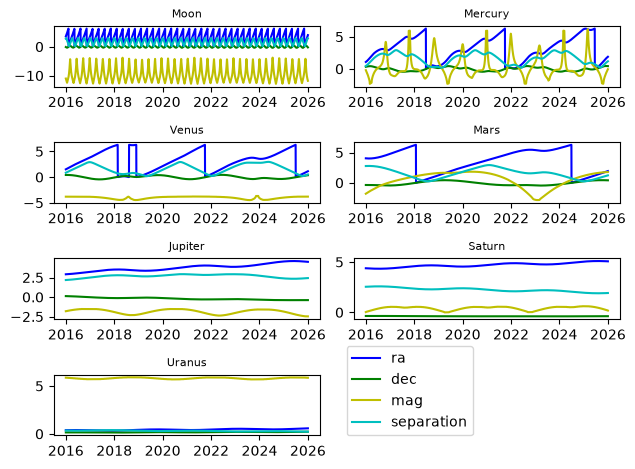

<class 'dict'>


In [31]:
import matplotlib.pylab as plt
import numpy as np

xAxis = np.linspace(2016, 2026, int(rangAnys * (8760/resolucio))) # TODO: NO FORÇAR EL RANG
planetsArray = {}

for j, planet in enumerate(planets):
    values = {'ra': {}, 'dec': {}, 'mag': {}, 'size': {}, 'separation': {}}

    for i in range(len(measurings[planet.name])):
        values["ra"][i] = list(measurings[planet.name].values())[i]["ra"]
        values["dec"][i] = list(measurings[planet.name].values())[i]["dec"]
        values["mag"][i] = list(measurings[planet.name].values())[i]["mag"]
        values["size"][i] = list(measurings[planet.name].values())[i]["size"]
        values["separation"][i] = list(measurings[planet.name].values())[i]["separation"]

    # pretty(values)

    planetsArray[planet.name] = values

    ax = plt.subplot(4, 2, j+1)
    
    ax.plot(xAxis, values["ra"].values(), 'b', label="ra")
    ax.plot(xAxis, values["dec"].values(), 'g', label="dec")
    ax.plot(xAxis, values["mag"].values(), 'y', label="mag")
    # ax.plot(xAxis, values["size"].values(), 'r', label="size")
    ax.plot(xAxis, values["separation"].values(), 'c', label="separation")
    ax.set_title(planet.name, fontsize=8)


plt.tight_layout()
plt.legend(loc=(1.1,0))
plt.show()

print(type(planetsArray))

# Get planets within viewing scope

In [108]:
# Using ephem.separation

coords = (str(observer.lat), str(observer.lon))
coords = ephem.Equatorial(*coords)

viewing_angle = ephem.degrees("55:00:00.0") # String = degrees
print(viewing_angle)

visiblePlanets = {}


for j in range(len(measurings["Moon"])):
    visiblePlanetsAtThisTime = {}
    for i, planet in enumerate(planets):
        separation = list(measurings[planet.name].values())[j]['separation']
        if(separation < viewing_angle):
            time = list(measurings[planet.name].keys())[j]
            # print('%s is visible from %s at %s with %s degrees separation' % (planet.name, observer.name, time, separation))
            visiblePlanetsAtThisTime[planet.name] = {'separation': separation, 'mag': planet.mag, 'size': planet.size}
    # print(visiblePlanetsAtThisTime)
    visiblePlanets[time] = {**visiblePlanetsAtThisTime}

pretty(visiblePlanets)


55:00:00.0
2016/6/15 03:00:00
	Mercury
		separation
			25:30:41.5
		mag
			-0.06
		size
			6.807798862457275
	Venus
		separation
			48:30:57.8
		mag
			-3.8
		size
			10.337891578674316
	Uranus
		separation
			20:11:06.9
		mag
			5.86
		size
			3.4367313385009766
2016/6/15 15:00:00
	Mercury
		separation
			26:12:31.6
		mag
			-0.06
		size
			6.807798862457275
	Venus
		separation
			49:06:13.8
		mag
			-3.8
		size
			10.337891578674316
	Uranus
		separation
			20:10:19.6
		mag
			5.86
		size
			3.4367313385009766
2016/6/16 03:00:00
	Mercury
		separation
			26:55:40.9
		mag
			-0.06
		size
			6.807798862457275
	Venus
		separation
			49:41:50.2
		mag
			-3.8
		size
			10.337891578674316
	Uranus
		separation
			20:09:32.0
		mag
			5.86
		size
			3.4367313385009766
2016/6/16 15:00:00
	Mercury
		separation
			27:39:11.9
		mag
			-0.06
		size
			6.807798862457275
	Venus
		separation
			50:17:09.1
		mag
			-3.8
		size
			10.337891578674316
	Uranus
		separation
			20:08:45.6
		mag
			5.86
		size

In [89]:
import rtmidi
import time as t

midiout = rtmidi.MidiOut()
available_ports = midiout.get_ports()

if available_ports:
    midiout.open_port(0)
else:
    midiout.open_virtual_port("Virtual Output")

print(midiout.get_port_name(0))

with midiout:
    for i, date in enumerate(visiblePlanets):
        planetsVisibleNow = visiblePlanets[date]
        # print(date, planetsVisibleNow)
        notes_on = []
        notes_off = []
        for i, planet in enumerate(planetsVisibleNow):
            planetInfo = planetsVisibleNow[planet]
            note = planetInfo['separation'] * 127
            amplitude = abs(planetInfo['mag'] * 10)
            
            for j, plan in enumerate(planets):
                if planet == plan.name:
                    chan = j
                    break
                else:
                    chan = -1

            NOTE_ON = 0x90
            NOTE_OFF = 0x80
            status_on = NOTE_ON | (chan)
            status_off = NOTE_OFF | (chan)

            note_on = [status_on, note, amplitude]
            notes_on.append(note_on)
            note_off = [status_off, note, amplitude]
            notes_off.append(note_off)

        # print(notes_on, notes_off)
        for message in notes_on:
            midiout.send_message(message)
        t.sleep(.5)
        for message in notes_off:
            midiout.send_message(message)

IAC Driver Bus 1
Mercury
{'separation': 0.4452603694468723, 'mag': -0.06, 'size': 6.807798862457275}
Venus
{'separation': 0.8467649631166818, 'mag': -3.8, 'size': 10.337891578674316}
Uranus
{'separation': 0.35229909487353184, 'mag': 5.86, 'size': 3.4367313385009766}
Mercury
{'separation': 0.4574296974245041, 'mag': -0.06, 'size': 6.807798862457275}
Venus
{'separation': 0.8570237936374345, 'mag': -3.8, 'size': 10.337891578674316}
Uranus
{'separation': 0.35206971287786026, 'mag': 5.86, 'size': 3.4367313385009766}
Mercury
{'separation': 0.4699826268443712, 'mag': -0.06, 'size': 6.807798862457275}
Venus
{'separation': 0.8673809404285799, 'mag': -3.8, 'size': 10.337891578674316}
Uranus
{'separation': 0.35183876907262424, 'mag': 5.86, 'size': 3.4367313385009766}
Mercury
{'separation': 0.4826411984111076, 'mag': -0.06, 'size': 6.807798862457275}
Venus
{'separation': 0.8776540079729178, 'mag': -3.8, 'size': 10.337891578674316}
Uranus
{'separation': 0.35161386658744637, 'mag': 5.86, 'size': 3.4

KeyboardInterrupt: 